# 📱 Mobile Recommendation System

This project uses Machine Learning to recommend mobile devices
based on user needs.

Features:
- Price
- RAM
- Storage
- Camera
- Battery
- 5G

In [1]:
!pip install pandas scikit-learn matplotlib ipywidgets


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import ipywidgets as widgets
from IPython.display import display, clear_output

In [3]:
df = pd.read_csv("mobile_data.csv")
df.head()

,brand,model,price_thb,ram_gb,storage_gb,screen_size_inch,battery_mah,camera_mp,support_5g,os,cpu
0,Samsung,Galaxy A54,12990,8,256,6.4,5000,50,Yes,Android,Exynos 1380
1,Samsung,Galaxy A34,10990,8,128,6.6,5000,48,Yes,Android,Dimensity 1080
2,Samsung,Galaxy A14,5990,4,128,6.6,5000,50,No,Android,Exynos 850
3,Samsung,Galaxy A04,3990,3,32,6.5,5000,13,No,Android,Exynos 850
4,Samsung,Galaxy S23,32990,8,256,6.1,3900,50,Yes,Android,Snapdragon 8 Gen 2


In [4]:
df["support_5g"] = df["support_5g"].map({"Yes":1, "No":0})

## 📊 Data Analysis

In [5]:
df.describe()

,price_thb,ram_gb,storage_gb,screen_size_inch,battery_mah,camera_mp,support_5g
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000
mean,15330.000000,7.220000,177.280000,6.490800,4725.380000,48.50000,0.660000
std,9174.298616,2.581646,76.824486,0.347368,751.785355,20.91894,0.478518
min,3990.000000,3.000000,32.000000,4.700000,2018.000000,12.00000,0.000000
25%,8115.000000,6.000000,128.000000,6.430000,4581.250000,48.50000,0.000000
50%,12990.000000,8.000000,128.000000,6.600000,5000.000000,50.00000,1.000000
75%,22240.000000,8.000000,256.000000,6.700000,5000.000000,50.00000,1.000000
max,37990.000000,16.000000,256.000000,6.800000,6000.000000,108.00000,1.000000


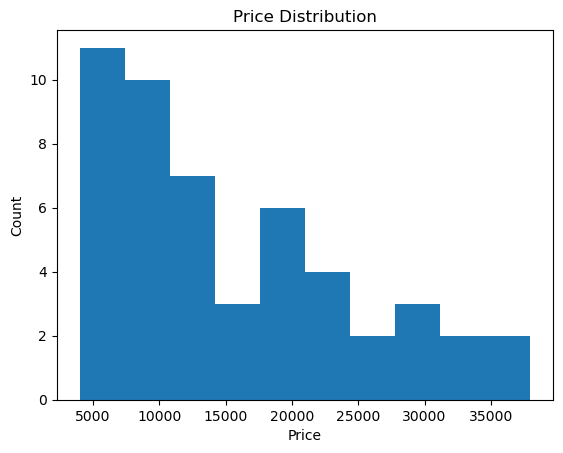

In [6]:
plt.figure()
plt.hist(df["price_thb"])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

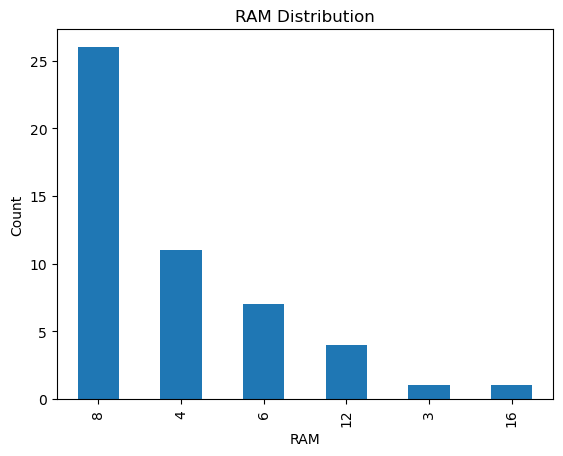

In [7]:
plt.figure()
df["ram_gb"].value_counts().plot(kind='bar')
plt.title("RAM Distribution")
plt.xlabel("RAM")
plt.ylabel("Count")
plt.show()

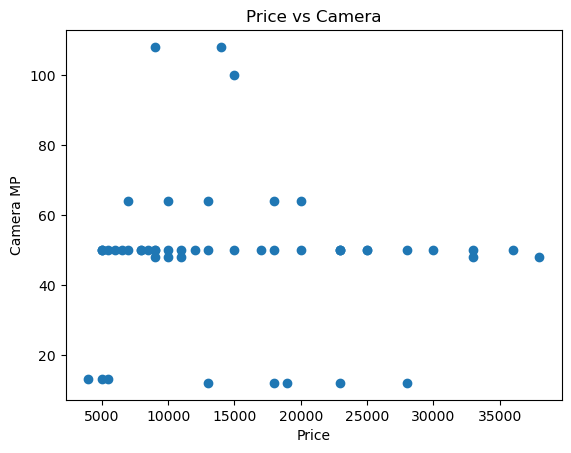

In [8]:
plt.figure()
plt.scatter(df["price_thb"], df["camera_mp"])
plt.xlabel("Price")
plt.ylabel("Camera MP")
plt.title("Price vs Camera")
plt.show()

## 🎯 Select the desired mobile specs

In [9]:
features = ["price_thb","ram_gb","storage_gb","screen_size_inch","battery_mah","camera_mp","support_5g"]
X = df[features]

In [ ]:
price = widgets.IntSlider(value=10000, min=3000, max=40000, step=1000, description='Budget 💰')
ram = widgets.Dropdown(options=sorted(df["ram_gb"].unique()), description='RAM 📊')
storage = widgets.Dropdown(options=sorted(df["storage_gb"].unique()), description='Storage 💾')
screen = widgets.FloatSlider(value=6.5, min=4.5, max=7.5, step=0.1, description='Screen 📱')
battery = widgets.IntSlider(value=5000, min=2000, max=7000, step=500, description='Battery 🔋')
camera = widgets.IntSlider(value=50, min=10, max=120, step=2, description='Camera 📸')
support_5g = widgets.ToggleButtons(options=[('Yes',1),('No',0)], description='5G 📶')

button = widgets.Button(description="🔍 Recommended mobile phones", button_style='success')
output = widgets.Output()

display(price, ram, storage, screen, battery, camera, support_5g, button, output)

IntSlider(value=10000, description='Budget 💰', max=40000, min=3000, step=1000)

Dropdown(description='RAM 📊', options=(3, 4, 6, 8, 12, 16), value=3)

Dropdown(description='Storage 💾', options=(32, 64, 128, 256), value=32)

FloatSlider(value=6.5, description='Screen 📱', max=7.5, min=4.5)

IntSlider(value=5000, description='Battery 🔋', max=7000, min=2000, step=500)

IntSlider(value=50, description='Camera 📸', max=120, min=10, step=2)

ToggleButtons(description='5G 📶', options=(('Yes', 1), ('No', 0)), value=1)

Button(button_style='success', description='🔍 Recommended mobile phones', style=ButtonStyle())

Output()

In [11]:
def recommend(b):
    with output:
        clear_output()

        user_input = {
            "price_thb": price.value,
            "ram_gb": ram.value,
            "storage_gb": storage.value,
            "screen_size_inch": screen.value,
            "battery_mah": battery.value,
            "camera_mp": camera.value,
            "support_5g": support_5g.value
        }

        user_df = pd.DataFrame([user_input])

        similarity = cosine_similarity(user_df, X)
        df["score"] = similarity[0]

        recommended = df.sort_values(by="score", ascending=False).head(5)

        print("📱 Recommended mobile models:\n")

        for i, row in recommended.iterrows():
            print(f"{row['brand']} {row['model']}")
            print(f"💰 Price: {row['price_thb']} บาท")
            print(f"📊 RAM: {row['ram_gb']}GB | Storage: {row['storage_gb']}GB")
            print(f"📸 Camera: {row['camera_mp']}MP | 🔋 {row['battery_mah']}mAh")
            print(f"📶 5G: {'Yes' if row['support_5g']==1 else 'No'}")
            print("----------------------")

button.on_click(recommend)